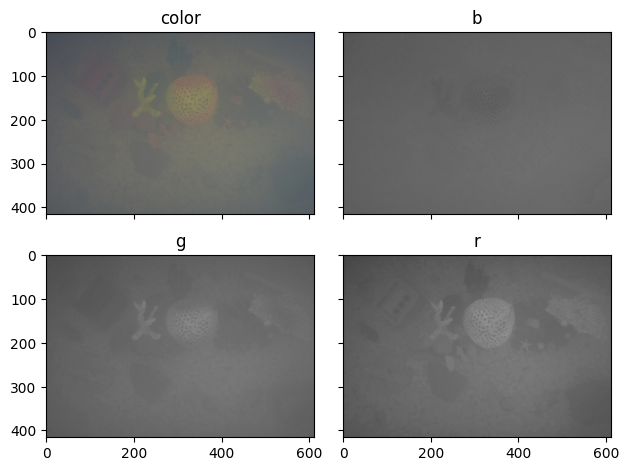

In [5]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import dataclass

from pathlib import Path

from common import OrderedImage, FloatArray, Uint8Array
from plotting import plot_imgs, plot_img, plot_channels
from main import StatType, MinMaxMean, Stats, load_img, color_loss, channel_correction, basic_CLAHE_float, basic_CLAHE_u8_cl
from clahe import tclahe

PATH = Path('milk') / 'a15.jpg'
# PATH = Path('lake') / 'blue_blur.png'

img = load_img(PATH)
plot_channels(img)

# B. Dynamic Turbid Color Correction

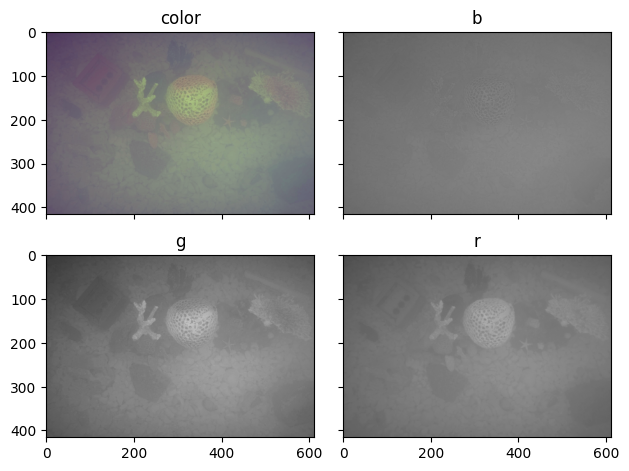

In [6]:
channel_correction(img)
plot_channels(img)

# C. Advanced De-Turbid Scene Model

## Using OpenCV (static clip limit)

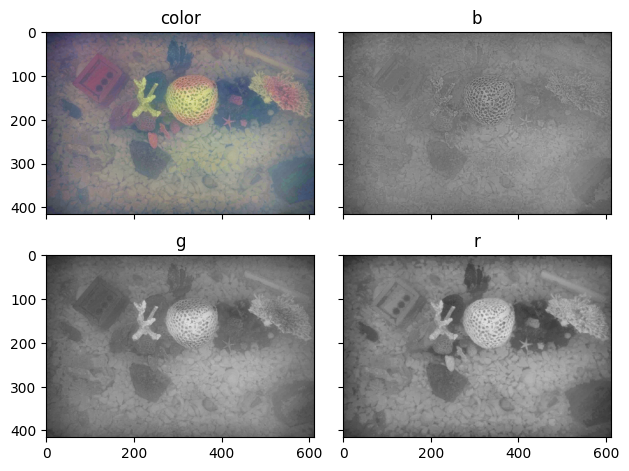

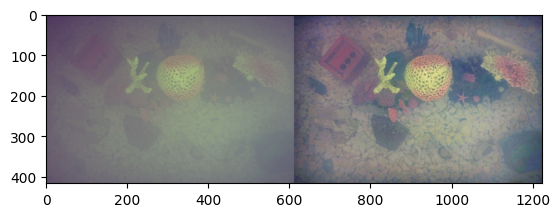

In [7]:
clahed_static = basic_CLAHE_float(img)
plot_channels(clahed_static)
plot_img(np.hstack((img.cl, clahed_static.cl)))

# TODO: rewrite CLAHE to have dynamic clip limit based on block turbidity estimation

## Dynamic Clip Limit

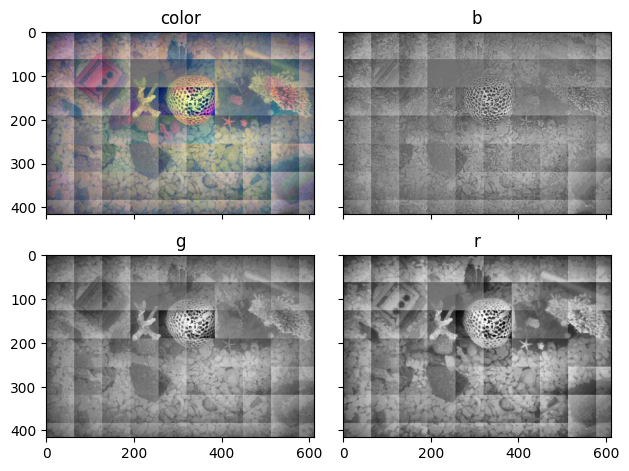

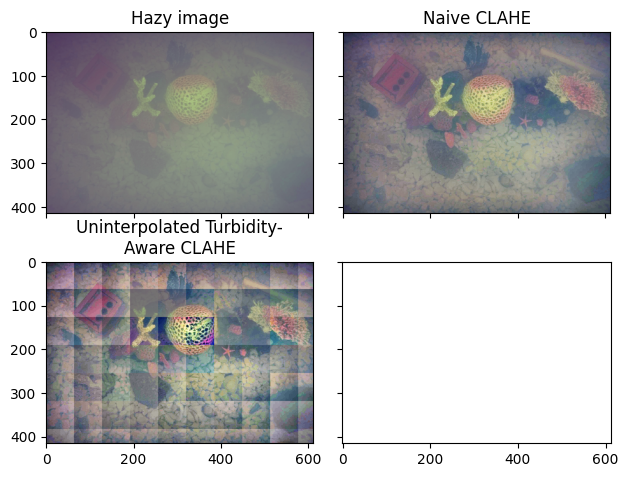

In [ ]:
def plot_hist(img_cl, title):
    plt.title(f'{title} ({img_cl.min(), img_cl.max()})')
    plt.plot(cv2.calcHist([(img_cl * 255).astype(np.uint8)], channels=[0], mask=None, histSize=[256], ranges=[0, 256]))
    plt.show()

clahed_dynamic = tclahe(img, n=64, interpolate=True)
plot_channels(clahed_dynamic)

clahed_dynamic_uninterpolated = tclahe(img, n=64, interpolate=False)
plot_channels(clahed_dynamic_uninterpolated)

plot_imgs([img, clahed_static, clahed_dynamic_uninterpolated, clahed_dynamic],
          titles=['Hazy image', 'Naive CLAHE', 'Uninterpolated Turbidity-\nAware CLAHE', '\nInterpolated Turbidity-\nAware CLAHE'])